# FCC-ee Impedance/Wake Model: Transverse Dipolar Impedance $Z_{x,y}$ ($\Omega$/m)

## Import dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.ticker import LogLocator
import matplotlib.ticker as ticker

## Multiplicative factors for elements with the same model

In [2]:
N_tot_bellows=10000 
N_tot_BPM=10000   
N_tot_cavities=132
N_tot_RF_tapers=33

## Yokoya form factors to account for pipe winglets

In [3]:
F_xdip=0.92
F_ydip=0.99

## Weight factor to consider tat Z_tot= 2*Z_IW2D + Z_geom

In [21]:
F_IW2D_coll = 2

# weight factor to consider geom contrubution
F_geom_coll = 0

## Input and output folders

In [22]:
project_root   = Path.cwd().parent 
element_folder = project_root / "elements"
image_folder   = project_root / "images" / "GHC_v23" / "optimized" / "imp"
output_folder  = project_root / "output" / "GHC_v23" / "optimized" / "imp"

# crea solo dove serve scrivere
os.makedirs(image_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)


## Upload elements data

In [23]:
# Bellows
Z_bellow_x = np.loadtxt(element_folder / "bellows" / "imp" / "Bellows_Z_NormDipImpX_sigma04mm.txt", skiprows=0)
Z_bellow_y = np.loadtxt(element_folder / "bellows" / "imp" / "Bellows_Z_NormDipImpY_sigma04mm.txt", skiprows=0)

# BPM 
Z_BPM = np.loadtxt(element_folder / "BPMs" / "imp" / "BPMs_Zx_cst_noNorm.txt",skiprows=0)
Z_BPM[:,1:3]=-Z_BPM[:,1:3]/3e-3 # normalized to transverse displacement and with opposite sign

# RF cavities
Z_cavity = np.loadtxt(element_folder / "RF_cavity" / "imp" / "RF_cavity_400MHz_Ztrans_FFT_wake.txt",skiprows=0)
Z_cavity[:,1:3]=Z_cavity[:,1:3]  # in Ohm/m


# tapers
Z_taper_in_RE = np.loadtxt(element_folder / "tapers" / "imp" / "taper_in_Z_Re_0.4_mm_transverse_dip.txt",skiprows=2)
Z_taper_in_IM = np.loadtxt(element_folder / "tapers" / "imp" / "taper_in_Z_Im_0.4_mm_transverse_dip.txt",skiprows=2)
Z_taper=np.zeros((len(Z_taper_in_RE[:,0]),3))
Z_taper[:,:-1] = Z_taper_in_RE
Z_taper[:,1] = Z_taper[:,1]*1e3 # in Ohm/m
Z_taper[:,2] = Z_taper_in_IM[:,1]*1e3 # in Ohm/m

Z_taper_out_RE = np.loadtxt(element_folder / "tapers" / "imp" / "taper_out_Z_Re_0.4_mm_transverse_dip.txt",skiprows=2)
Z_taper_out_IM = np.loadtxt(element_folder / "tapers" / "imp" / "taper_out_Z_Im_0.4_mm_transverse_dip.txt",skiprows=2)
Z_taper[:,1] = Z_taper[:,1]+Z_taper_out_RE[:,1]*1e3
Z_taper[:,2]=Z_taper[:,2]+Z_taper_out_IM[:,1]*1e3 # in Ohm/m

# Beam pipe (RW) 
Z_RW_150nm_x_RE = np.loadtxt(element_folder / "pipe" / "30mm_neg150nm" / "imp" / "RW_pipe_iw2d_Zx_dip_Re_150nm.txt",skiprows=0)
Z_RW_150nm_x_IM = np.loadtxt(element_folder / "pipe" / "30mm_neg150nm" / "imp" / "RW_pipe_iw2d_Zx_dip_Im_150nm.txt",skiprows=0)
Z_RW_150nm_x_RE[:,0]=Z_RW_150nm_x_RE[:,0]*1e-9 # from Hz to GHz 
Z_RW_150nm_x_IM[:,0]=Z_RW_150nm_x_IM[:,0]*1e-9 # from Hz to GHz
Z_RW_150nm_x_RE[:,1]=Z_RW_150nm_x_RE[:,1]*F_xdip # form factor
Z_RW_150nm_x_IM[:,1]=Z_RW_150nm_x_IM[:,1]*F_xdip # form factor

Z_RW_150nm_y_RE=np.loadtxt(element_folder / "pipe" / "30mm_neg150nm" / "imp" / "RW_pipe_iw2d_Zx_dip_Re_150nm.txt",skiprows=0)
Z_RW_150nm_y_IM=np.loadtxt(element_folder / "pipe" / "30mm_neg150nm" / "imp" / "RW_pipe_iw2d_Zx_dip_Im_150nm.txt",skiprows=0)
Z_RW_150nm_y_RE[:,0]=Z_RW_150nm_y_RE[:,0]*1e-9 # from Hz to GHz 
Z_RW_150nm_y_IM[:,0]=Z_RW_150nm_y_IM[:,0]*1e-9 # from Hz to GHz
Z_RW_150nm_y_RE[:,1]=Z_RW_150nm_y_RE[:,1]*F_ydip # form factor
Z_RW_150nm_y_IM[:,1]=Z_RW_150nm_y_IM[:,1]*F_ydip # form factor

# RW collimators
Z_coll_IW2D_x_RE=np.loadtxt(element_folder / "collimators" / "RW" / "GHC" / "v23" / "tot" / "imp" / "Coll_iw2d_Zx_dip_Re_150nm.txt",skiprows=0)
Z_coll_IW2D_x_IM=np.loadtxt(element_folder / "collimators" / "RW" / "GHC" / "v23" / "tot" / "imp" / "Coll_iw2d_Zx_dip_Im_150nm.txt",skiprows=0)
Z_coll_IW2D_x_RE[:,0]=Z_coll_IW2D_x_RE[:,0]*1e-9 # from Hz to GHz
Z_coll_IW2D_x_IM[:,0]=Z_coll_IW2D_x_IM[:,0]*1e-9 # from Hz to GHz

Z_coll_IW2D_y_RE=np.loadtxt(element_folder / "collimators" / "RW" / "GHC" / "v23" / "tot" / "imp" / "Coll_iw2d_Zy_dip_Re_150nm.txt",skiprows=0)
Z_coll_IW2D_y_IM=np.loadtxt(element_folder / "collimators" / "RW" / "GHC" / "v23" / "tot" / "imp" / "Coll_iw2d_Zy_dip_Im_150nm.txt",skiprows=0)
Z_coll_IW2D_y_RE[:,0]=Z_coll_IW2D_y_RE[:,0]*1e-9 # from Hz to GHz
Z_coll_IW2D_y_IM[:,0]=Z_coll_IW2D_y_IM[:,0]*1e-9 # from Hz to GHz

## Frequency interpolation

In [24]:
frequency=np.linspace(0,50,5001)

Z_belx=np.zeros((len(frequency),len(frequency)))
Z_belx[:,0]=np.interp(frequency,Z_bellow_x[:,0],Z_bellow_x[:,1])
Z_belx[:,1]=np.interp(frequency,Z_bellow_x[:,0],Z_bellow_x[:,2])
Z_belx=Z_belx*N_tot_bellows

Z_bely=np.zeros((len(frequency),len(frequency)))
Z_bely[:,0]=np.interp(frequency,Z_bellow_y[:,0],Z_bellow_y[:,1])
Z_bely[:,1]=np.interp(frequency,Z_bellow_y[:,0],Z_bellow_y[:,2])
Z_bely=Z_bely*N_tot_bellows

Z_bpm=np.zeros((len(frequency),len(frequency)))
Z_bpm[:,0]=np.interp(frequency,Z_BPM[:,0],Z_BPM[:,1])
Z_bpm[:,1]=np.interp(frequency,Z_BPM[:,0],Z_BPM[:,2])
Z_bpm=Z_bpm*N_tot_BPM

Z_rw_x=np.zeros((len(frequency),len(frequency)))
Z_rw_x[:,0]=np.interp(frequency,Z_RW_150nm_x_RE[:,0],Z_RW_150nm_x_RE[:,1])
Z_rw_x[:,1]=np.interp(frequency,Z_RW_150nm_x_IM[:,0],Z_RW_150nm_x_IM[:,1])


Z_rw_y=np.zeros((len(frequency),len(frequency)))
Z_rw_y[:,0]=np.interp(frequency,Z_RW_150nm_y_RE[:,0],Z_RW_150nm_y_RE[:,1])
Z_rw_y[:,1]=np.interp(frequency,Z_RW_150nm_y_IM[:,0],Z_RW_150nm_y_IM[:,1])

Z_cav=np.zeros((len(frequency),len(frequency)))
Z_cav[:,0]=np.interp(frequency,Z_cavity[:,0],Z_cavity[:,1])
Z_cav[:,1]=np.interp(frequency,Z_cavity[:,0],Z_cavity[:,2])
Z_cav=Z_cav*N_tot_cavities

Z_RF_tap=np.zeros((len(frequency),len(frequency)))
Z_RF_tap[:,0]=np.interp(frequency,Z_taper[:,0],Z_taper[:,1])
Z_RF_tap[:,1]=np.interp(frequency,Z_taper[:,0],Z_taper[:,2])
Z_RF_tap=Z_RF_tap*N_tot_RF_tapers

Z_coll_iw2d_x=np.zeros((len(frequency),len(frequency)))
Z_coll_iw2d_x[:,0]=np.interp(frequency,Z_coll_IW2D_x_RE[:,0],Z_coll_IW2D_x_RE[:,1])
Z_coll_iw2d_x[:,1]=np.interp(frequency,Z_coll_IW2D_x_IM[:,0],Z_coll_IW2D_x_IM[:,1])

Z_coll_iw2d_y=np.zeros((len(frequency),len(frequency)))
Z_coll_iw2d_y[:,0]=np.interp(frequency,Z_coll_IW2D_y_RE[:,0],Z_coll_IW2D_y_RE[:,1])
Z_coll_iw2d_y[:,1]=np.interp(frequency,Z_coll_IW2D_y_IM[:,0],Z_coll_IW2D_y_IM[:,1])

## Evaluate total tranverse dipolar impedance $Z^{tot}_{x,y}$ ($\Omega$/m)

In [25]:
Z_tot_coll_RW_x = F_IW2D_coll*(Z_coll_iw2d_x)
Z_tot_coll_RW_y = F_IW2D_coll*(Z_coll_iw2d_y)

Z_coll_geom_x = Z_coll_iw2d_x*F_geom_coll
Z_coll_geom_y = Z_coll_iw2d_x*F_geom_coll

Z_coll_tot_x = Z_coll_geom_x + Z_tot_coll_RW_x
Z_coll_tot_y = Z_coll_geom_y + Z_tot_coll_RW_y

Z_totx=Z_belx+Z_bpm+Z_rw_x+Z_cav+Z_RF_tap+Z_coll_tot_x
Z_toty=Z_bely+Z_bpm+Z_rw_y+Z_cav+Z_RF_tap+Z_coll_tot_y



In [26]:
# %pip install ipympl ipywidgets

## Elements contribution:  Im[$Z_{y}$] ($\Omega$/m)


In [27]:
fntsz = 18
mpl.rcParams.update({
    'font.size': fntsz,
    'axes.titlesize': fntsz,
    'axes.labelsize': fntsz,
    'xtick.labelsize': fntsz,
    'ytick.labelsize': fntsz,
    'legend.fontsize': fntsz-2, 
})

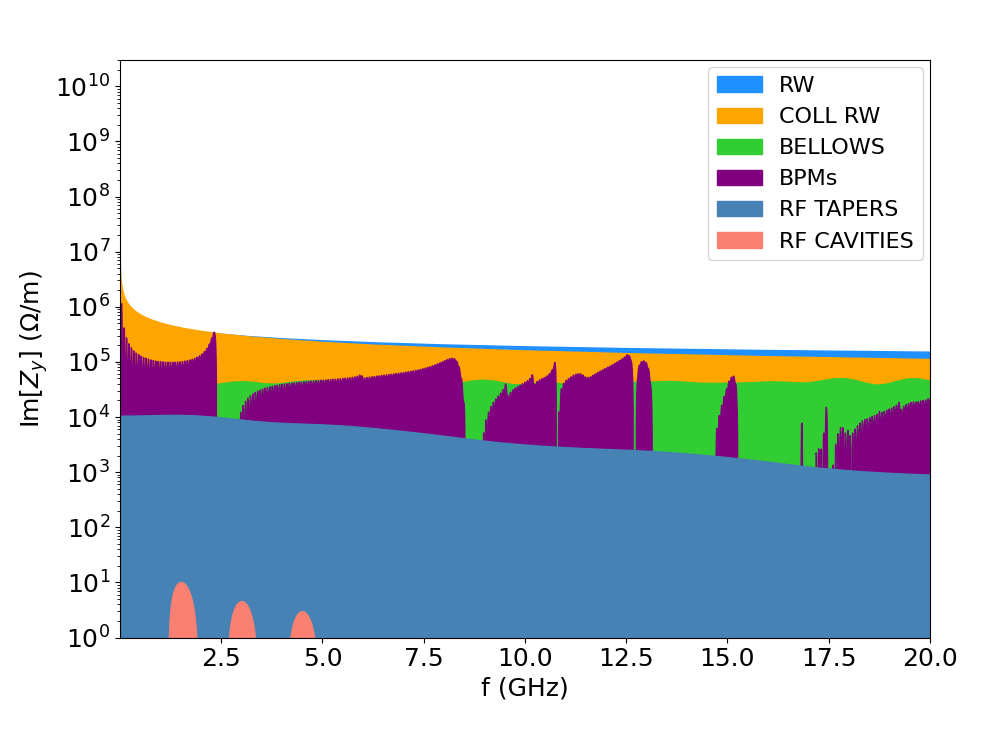

In [39]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'Im[$Z_{y}$] ($\Omega$/m)')

ax.fill_between(frequency, Z_rw_y[:, 1], color='dodgerblue', alpha=1, label='RW pipe')
ax.fill_between(frequency, Z_tot_coll_RW_y[:, 1], color='orange', alpha=1, label='Coll. RW')
ax.fill_between(frequency, Z_bely[:, 1], color='limegreen', alpha=1, label='Bellows')
ax.fill_between(frequency, Z_bpm[:, 1], color='purple', alpha=1, label='BPMs')
#ax.fill_between(frequency, Z_coll_geom_y, color='crimson', alpha=1, label='Coll. geom.')
ax.fill_between(frequency, Z_RF_tap[:, 1], color='steelblue', alpha=1, label='RF tapers')
ax.fill_between(frequency, Z_cav[:, 1], color='salmon', alpha=1, label='RF cavities')

legend_patches = [
    mpatches.Patch(color='dodgerblue', label='RW'),
    mpatches.Patch(color='orange', label='COLL RW'),
    mpatches.Patch(color='limegreen', label='BELLOWS'),
    mpatches.Patch(color='purple', label='BPMs'),
    mpatches.Patch(color='steelblue', label='RF TAPERS'),
    mpatches.Patch(color='salmon', label='RF CAVITIES')
]

ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.005, 1.007))

ax.set_xlim(1e-3, 20)
ax.set_ylim(1e0, 3e10)
ax.set_xscale('linear')
ax.set_yscale('log')
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=16))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=80)) 

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Zy_dip_Im_log_area.jpg", dpi=300, bbox_inches='tight')


## Elements contribution:  Im[$Z_{x}$] ($\Omega$/m)

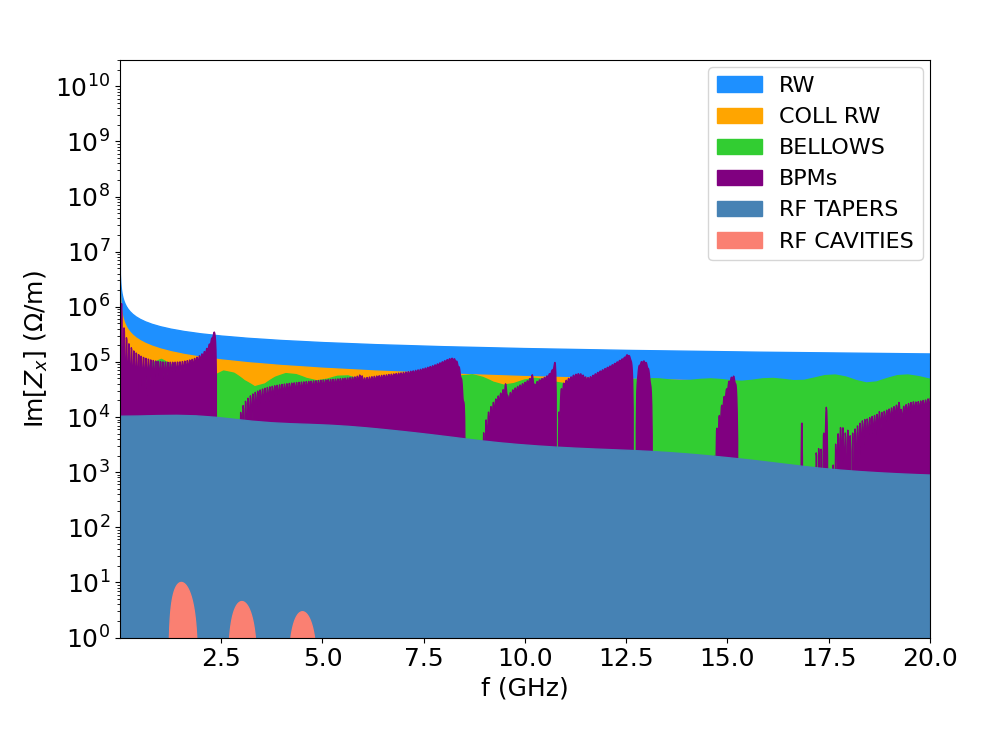

In [41]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'Im[$Z_{x}$] ($\Omega$/m)')


ax.fill_between(frequency, Z_rw_x[:, 1], color='dodgerblue', alpha=1, label='RW pipe')
ax.fill_between(frequency, Z_tot_coll_RW_x[:, 1], color='orange', alpha=1, label='Coll. RW')
ax.fill_between(frequency, Z_belx[:, 1], color='limegreen', alpha=1, label='Bellows')
ax.fill_between(frequency, Z_bpm[:, 1], color='purple', alpha=1, label='BPMs')
ax.fill_between(frequency, Z_RF_tap[:, 1], color='steelblue', alpha=1, label='RF tapers')
ax.fill_between(frequency, Z_cav[:, 1], color='salmon', alpha=1, label='RF cavities')

legend_patches = [
    mpatches.Patch(color='dodgerblue', label='RW'),
    mpatches.Patch(color='orange', label='COLL RW'),
    mpatches.Patch(color='limegreen', label='BELLOWS'),
    mpatches.Patch(color='purple', label='BPMs'),
    mpatches.Patch(color='steelblue', label='RF TAPERS'),
    mpatches.Patch(color='salmon', label='RF CAVITIES')
]

ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.005, 1.007))

ax.set_xlim(1e-3, 20)
ax.set_ylim(1e0, 3e10)
ax.set_xscale('linear')
ax.set_yscale('log')

ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=16))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=80)) 

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Zx_dip_Im_log_area.jpg", dpi=300, bbox_inches='tight')

## Elements contribution:  Re[$Z_{y}$] ($\Omega$/m)

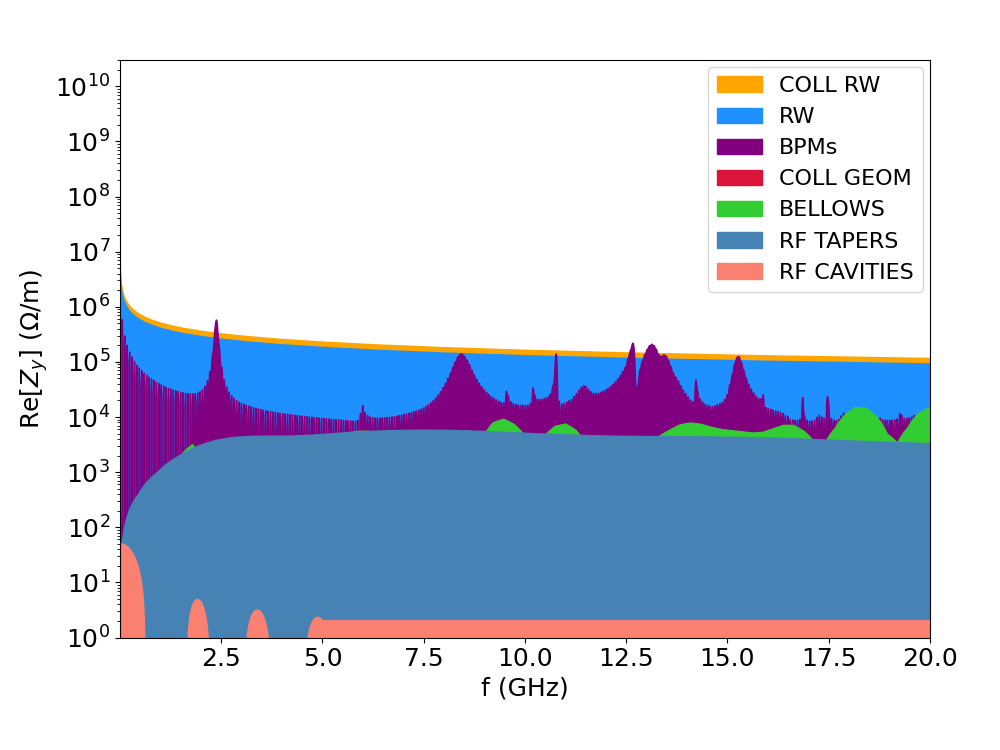

In [42]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'Re[$Z_{y}$] ($\Omega$/m)')

ax.fill_between(frequency, Z_tot_coll_RW_y[:, 0], color='orange', alpha=1, label='Coll. RW')
ax.fill_between(frequency, Z_rw_y[:, 0], color='dodgerblue', alpha=1, label='RW pipe')
ax.fill_between(frequency, Z_bpm[:, 0], color='purple', alpha=1, label='BPMs')
ax.fill_between(frequency, Z_bely[:, 0], color='limegreen', alpha=1, label='Bellows')
ax.fill_between(frequency, Z_RF_tap[:, 0], color='steelblue', alpha=1, label='RF tapers')
ax.fill_between(frequency, Z_cav[:, 0], color='salmon', alpha=1, label='RF cavities')

legend_patches = [
    mpatches.Patch(color='orange', label='COLL RW'),
    mpatches.Patch(color='dodgerblue', label='RW'),
    mpatches.Patch(color='purple', label='BPMs'),
    mpatches.Patch(color='crimson', label='COLL GEOM'),
    mpatches.Patch(color='limegreen', label='BELLOWS'),
    mpatches.Patch(color='steelblue', label='RF TAPERS'),
    mpatches.Patch(color='salmon', label='RF CAVITIES')
]

ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.005, 1.007))

ax.set_xlim(1e-3, 20)
ax.set_ylim(1e0, 3e10)
ax.set_xscale('linear')
ax.set_yscale('log')

ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=16))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=80)) 

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Zy_dip_Re_log_area.jpg", dpi=300, bbox_inches='tight')

## Elements contribution:  Re[$Z_{x}$] ($\Omega$/m)

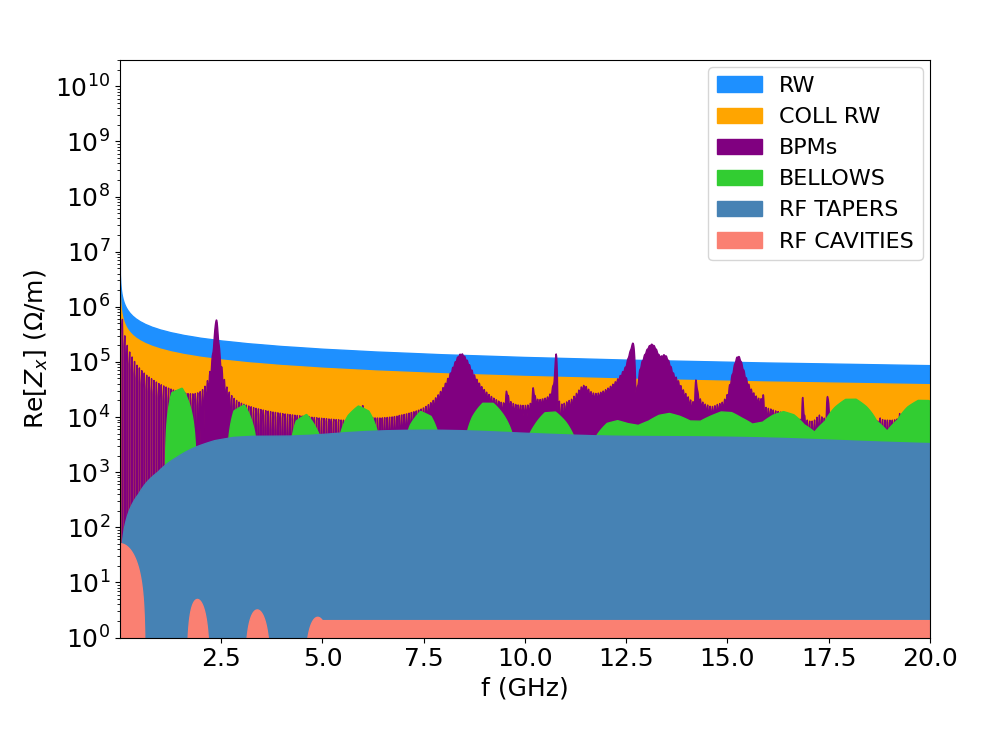

In [35]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'Re[$Z_{x}$] ($\Omega$/m)')

ax.fill_between(frequency, Z_rw_x[:, 0], color='dodgerblue', alpha=1, label='RW pipe')
ax.fill_between(frequency, Z_tot_coll_RW_x[:, 0], color='orange', alpha=1, label='Coll. RW')
ax.fill_between(frequency, Z_bpm[:, 0], color='purple', alpha=1, label='BPMs')
ax.fill_between(frequency, Z_belx[:, 0], color='limegreen', alpha=1, label='Bellows')
ax.fill_between(frequency, Z_RF_tap[:, 0], color='steelblue', alpha=1, label='RF tapers')
ax.fill_between(frequency, Z_cav[:, 0], color='salmon', alpha=1, label='RF cavities')

legend_patches = [
    mpatches.Patch(color='dodgerblue', label='RW'),
    mpatches.Patch(color='orange', label='COLL RW'),
    mpatches.Patch(color='purple', label='BPMs'),
    mpatches.Patch(color='limegreen', label='BELLOWS'),
    mpatches.Patch(color='steelblue', label='RF TAPERS'),
    mpatches.Patch(color='salmon', label='RF CAVITIES')
]

ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.005, 1.007))

ax.set_xlim(1e-3, 20)
ax.set_ylim(1e0, 3e10)
ax.set_xscale('linear')
ax.set_yscale('log')

ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=16))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=80)) 

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Zx_dip_Re_log_area.jpg", dpi=300, bbox_inches='tight')


## Total contribution: $Z^{tot}_{x,y}$ ($\Omega$/m)

NameError: name 'fonts_size' is not defined

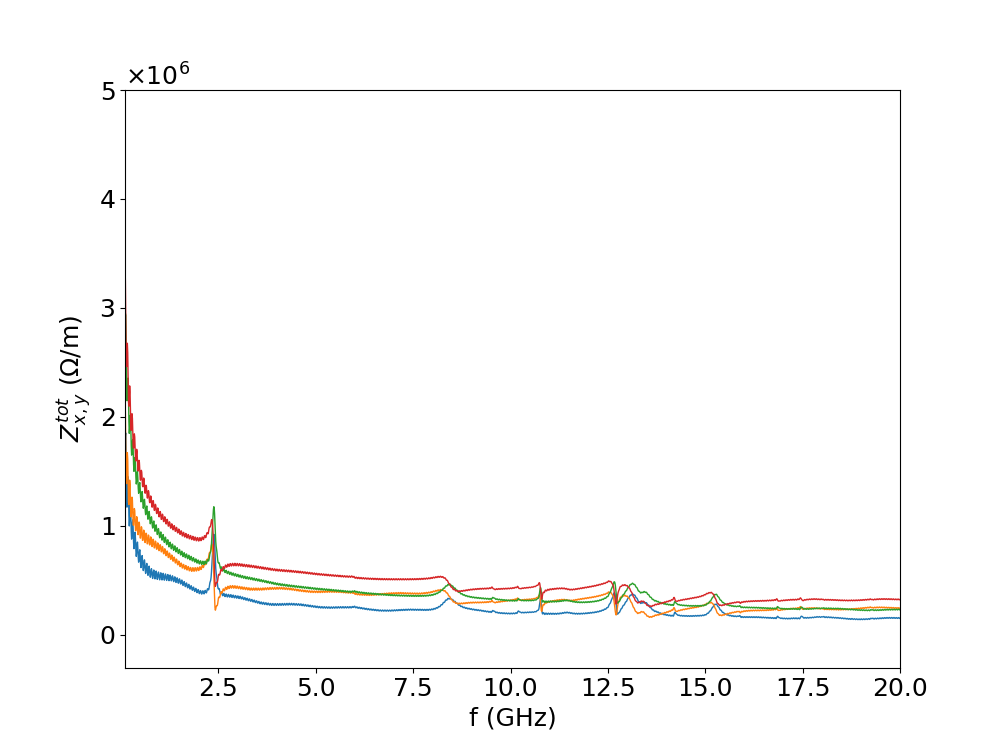

In [32]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'$Z^{tot}_{x,y}$ ($\Omega$/m)')

ax.plot(frequency,Z_totx[:,0],linewidth=1,label=r'Re[$Z_{x}$]')
ax.plot(frequency,Z_totx[:,1],linewidth=1,label=r'Im[$Z_{x}$]')
ax.plot(frequency,Z_toty[:,0],linewidth=1,label= r'Re[$Z_{y}$]')
ax.plot(frequency,Z_toty[:,1],linewidth=1,label=r'Im[$Z_{y}$]')

ax.set_xlim(1e-1,20)
ax.set_ylim(-3e5,0.5e7)
ax.set_xscale('linear')
ax.set_yscale('linear')

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((-2, 2))
ax.yaxis.get_offset_text().set_fontsize(fonts_size)
ax.legend( loc='upper right', fontsize=fonts_size, bbox_to_anchor=(1.005, 1.007))

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Z_dip_tot_lin.jpg", dpi=300, bbox_inches='tight')

### Export $Z^{tot}_{x,y}$ ($\Omega$/m)

In [34]:
head='f (GHz)        Re[Z] (Ohm/m)     Im[Z] (Ohm/m)'
np.savetxt(output_folder / "impedance_dip_X.txt", list(zip(frequency,Z_totx[:,0],Z_totx[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')
np.savetxt(output_folder / "impedance_dip_Y.txt", list(zip(frequency,Z_toty[:,0],Z_toty[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')

head='f (GHz)        Re[Z] (Ohm/m)     Im[Z] (Ohm/m)'
np.savetxt(output_folder / "coll_rw_dip_X.txt", list(zip(frequency,Z_coll_iw2d_x[:,0],Z_coll_iw2d_x[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')
np.savetxt(output_folder / "coll_rw_dip_Y.txt", list(zip(frequency,Z_coll_iw2d_y[:,0],Z_coll_iw2d_y[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')